# Testing Libraries

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=1
!export BART_CPU_ONLY=1
!export CUDA_LAUNCH_BLOCKING=1

import sys
import os

os.environ['BART_TOOLBOX_PATH'] = '/home/rinbha/Packages/bart-0.9.00'
os.environ['BART_CPU_ONLY'] = '1'
sys.path.append(os.path.join(os.environ['BART_TOOLBOX_PATH'], 'python'))

sys.path.insert(0, "/home/rinbha/Research/BPT/BPT_MOTUS/nonrigid-motion-bpt")
sys.path.insert(0, "/home/rinbha/Research/BPT/BPT_MOTUS/bpt_mrmotus_2025/bpt_mrmotus_2025/mrmotus_custom_packages/torch-interpol")
import sigpy as sp
import sigpy.mri as mr
import sigpy.plot as pl

import matplotlib.pyplot as plt
import numpy as np

# plotting
plt.rcParams.update({
    'axes.spines.top': False,           # Remove top spine
    'axes.spines.right': False,         # Remove right spine
    'axes.titlesize': 20,               # Increase title font size
    'axes.labelsize': 18,               # Increase axis label font size
    'xtick.labelsize': 16,              # Increase x-tick label size
    'ytick.labelsize': 16,              # Increase y-tick label size
    "text.usetex": False,                # Enable LaTeX 
    'legend.fontsize': 12,
    'font.family': 'Avenir' # Avenir font
})

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=1


## io

### Radial

In [12]:
# add paths
from bpt_motus.io import RadialArchive

In [32]:
# Path to radial ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/hires_ute"
# Create the object
radial = RadialArchive(inpdir)

radial.get_ksp(force_reload=False)

INFO: Loading cached raw radial data from /mikLKS/rinbha/BPT/MRMOTUS/test_data/hires_ute...


In [33]:
print(f"xk shape: {radial.xk_time.shape}")
print(f"coords shape: {radial.coords_time.shape}")
print(f"dcf shape: {radial.dcf_time.shape}")
print(f"time_ordering shape: {radial.time_ordering.shape}")

xk shape: (22, 39950, 1633)
coords shape: (39950, 1633, 3)
dcf shape: (39950, 1633)
time_ordering shape: (39950,)


In [36]:
radial.xk_time.shape

(22, 39950, 1633)

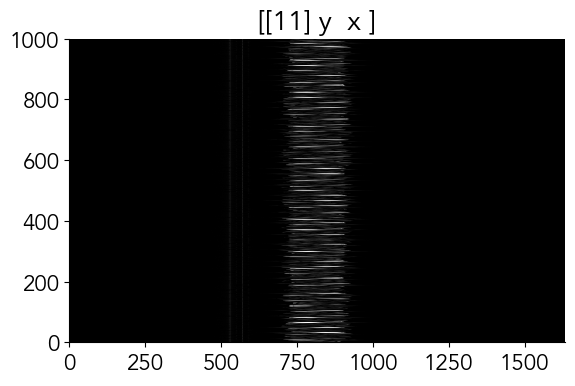

In [37]:
# Looking at first 1000 TRs
xk_f = sp.ifft(radial.xk_time[:,:1000], axes=(-1,))
pl.ImagePlot(xk_f)

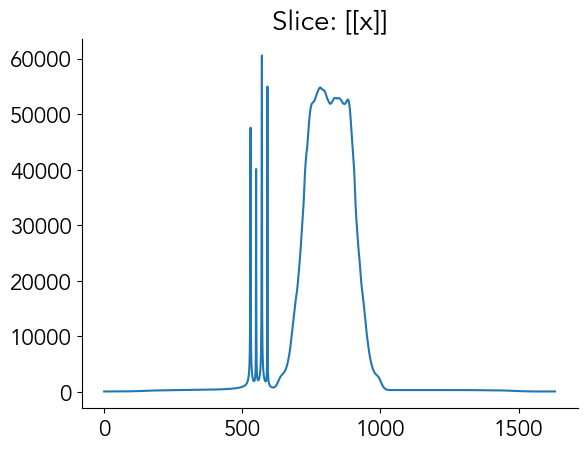

In [ ]:
# Looking at RSS of first 1000 TRs, all coils
xk_rss = sp.rss(xk_f, axes=(0,1))
pl.LinePlot(xk_rss)

In [ ]:
del radial

### Bravo

In [ ]:
from bpt_motus.io import BravoArchive

In [15]:
# Path to BRAVO ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bravo/raw_data"

# Create the object
bravo = BravoArchive(inpdir)

bravo.get_ksp(force_reload=False)

INFO: Cached data not found / used — extracting k-space.
INFO: Cached metadata not found / used — extracting.
INFO: No embedded or cached kacq found — estimating from control packets.


In [17]:
print(f"xk_time shape: {bravo.xk_time.shape}")
print(f"xk_recon shape: {bravo.xk_recon.shape}")
print(f"coords shape: {bravo.coords.shape}")

xk_time shape: (22, 58520, 384)
xk_recon shape: (22, 384, 308, 190)
coords shape: (58520, 384, 3)


In [18]:
im_recon = sp.ifft(bravo.xk_recon, axes=(-1,-2,-3))

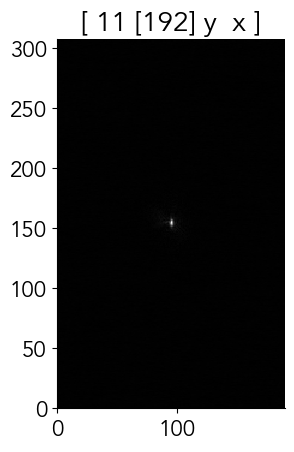

In [26]:
pl.ImagePlot(bravo.xk_recon)

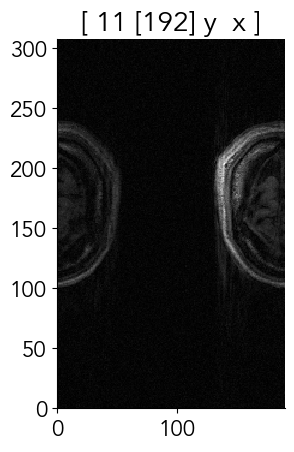

In [27]:
pl.ImagePlot(im_recon)

In [29]:
del bravo, im_recon

### Organize Radial Acquisitions into Phases

In [ ]:
from bpt_motus.io import SplitRadialAcq

In [ ]:
# Path to radial ScanArchive folder
inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/"
calib_source="hires"
no_motion_range=(0,15000)
calib_range=(20000,35000)
inf_range=(35000, None)
# Create the object
split_exp = SplitRadialAcq(inp_dir=inpdir, verbose=True, calib_source=calib_source, no_motion_range=no_motion_range, calib_range=calib_range, inf_range=inf_range)

In [ ]:
split_exp.run(force_reload=False)

INFO: Found split datasets. No need to split again.


## preprocessing

### Split k-space and BPT

In [15]:
from bpt_motus.preprocessing import SplitXkBPT

In [ ]:
# Split no motion data
nomotion_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/no_motion"
split_xk_bpt_nm = SplitXkBPT(inp_dir=nomotion_inpdir, verbose=True)
split_xk_bpt_nm.run()
# Split calibration data
calib_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/calib"
split_xk_bpt_c = SplitXkBPT(inp_dir=calib_inpdir, verbose=True)
split_xk_bpt_c.run()
# Split inference data
inf_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/inf"
split_xk_bpt_inf = SplitXkBPT(inp_dir=inf_inpdir, verbose=True)
split_xk_bpt_inf.run()

INFO: Cleaned k-space and raw BPT/PT signals found. Opening...


In [22]:
print(f"Cleaned k-space shape: {split_xk_bpt_nm.xk_cleaned.shape}")
print(f"BPT/PTs shape: {split_xk_bpt_nm.bpts.shape}")

Cleaned k-space shape: (6, 15000, 1633)
BPT/PTs shape: (4, 15000, 22)


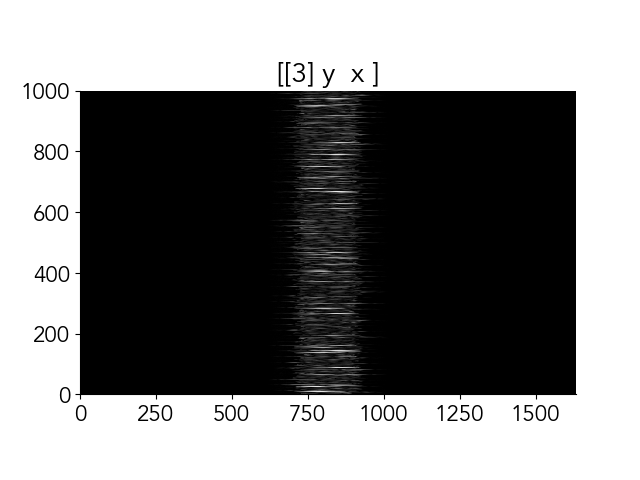

In [ ]:
xk_f = sp.ifft(split_xk_bpt_nm.xk_cleaned[:,:1000], axes=(-1,))
pl.ImagePlot(xk_f)

In [7]:
def plot_bpt(bpt, tr=1, window=1, shift=0, figsize=(10,10), titles = ["PT-1", "PT-2", "BPT-2", "BPT-1"]):
    nbpts, npe, ncoils = bpt.shape
    
    plt.figure(figsize=figsize)
    t = np.arange(npe)*tr
    # Plot
    for i in range(nbpts):
        plt.subplot(nbpts//2, 2, i+1)
        plt.plot(t, bpt[i] - np.mean(bpt[i],axis=0) + np.arange(ncoils)*shift);
        plt.title(titles[i])
        if i > 1:
            plt.xlabel("Time (s)")

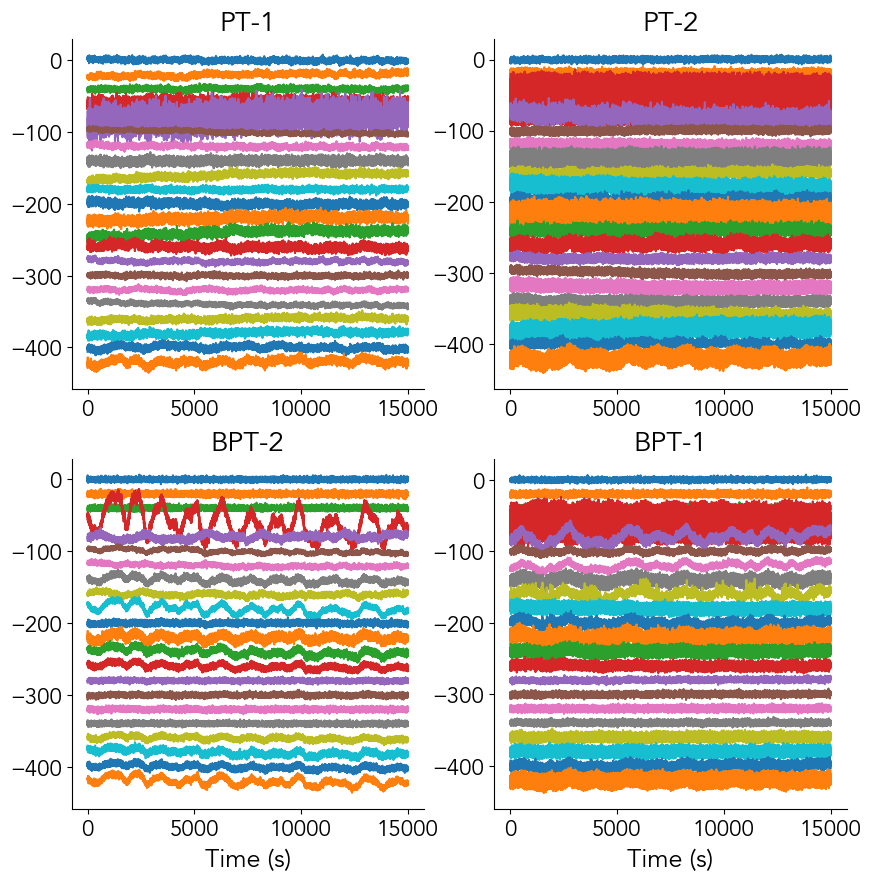

In [ ]:
plot_bpt(split_xk_bpt_c.bpts, shift = -20)

### Process BPT/PTs

In [25]:
from bpt_motus.preprocessing import ProcessBPT

In [ ]:
# Process calibration BPT
calib_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/calib"
proc_bpt_c = ProcessBPT(inp_dir=calib_inpdir, verbose=True, phase="calib")
proc_bpt_c.run()
# Process inference BPT
inf_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/inf"
proc_bpt_i = ProcessBPT(inp_dir=inf_inpdir, verbose=True, phase="inf")
proc_bpt_i.run()

INFO: Processed BPT/PTs found. Opening them...


In [ ]:
print(f"Processed BPT shape (calib): {proc_bpt_c.bpts_proc.shape}")
print(f"Processed BPT shape (inf): {proc_bpt_i.bpts_proc.shape}")

Processed BPT shape (calib): (15000, 16)


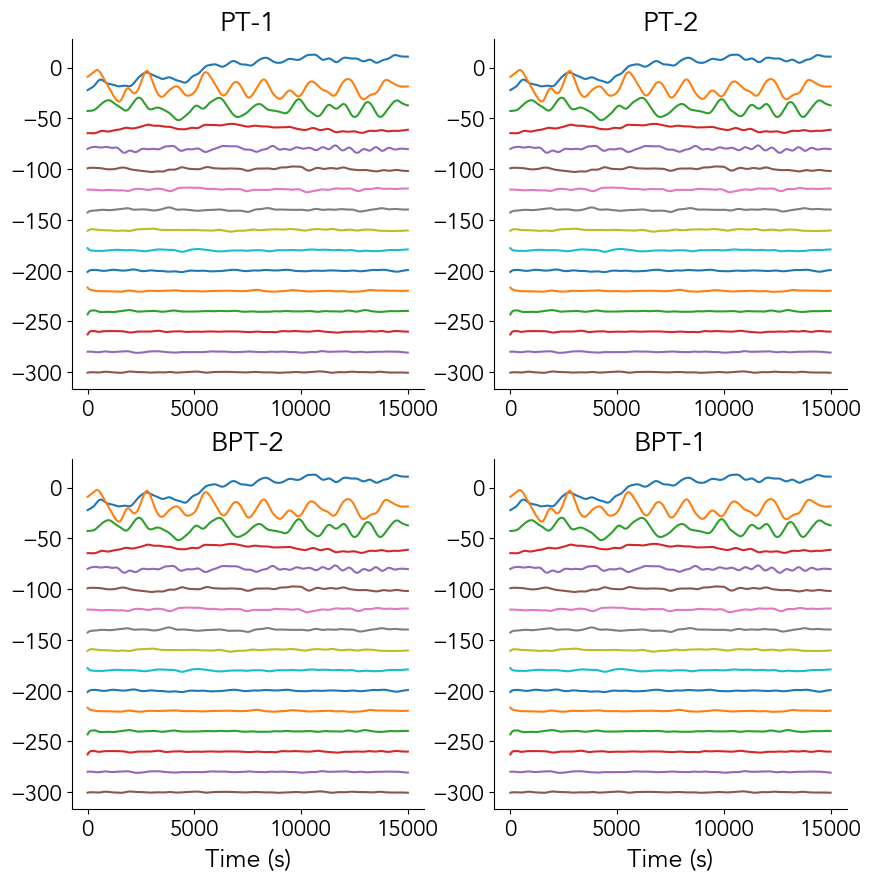

In [29]:
plot_bpt(np.tile(proc_bpt_c.bpts_proc, (4,1,1)), shift = -20)

### Process xk

#### No Motion Reference

In [10]:
from bpt_motus.preprocessing import NoMotionReference

In [11]:
# Path to no motion folder
nomotion_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/no_motion"

# Create the object
no_motion_reference = NoMotionReference(inp_dir=nomotion_inpdir, verbose=True)

In [12]:
no_motion_reference.run(force_reload=False)

INFO: Reference image and CSMs found. Opening...


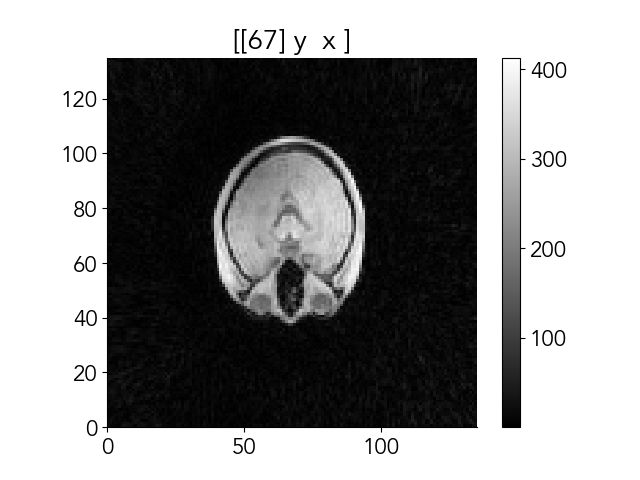

In [62]:
pl.ImagePlot(no_motion_reference.S, colormap='gray')

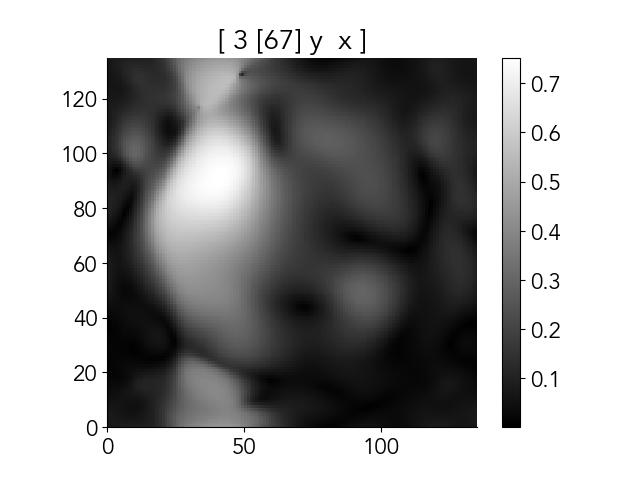

In [61]:
pl.ImagePlot(no_motion_reference.csm, colormap='gray')

#### Motion Frames

In [2]:
from bpt_motus.preprocessing import MotionFrames

In [ ]:
# Process calibration k-space with motion
calib_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/calib"
motion_frames_c = MotionFrames(inp_dir=calib_inpdir, verbose=True)
motion_frames_c.run(force_reload=False)
# Process inference k-space with motion
inf_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/inf"
motion_frames_i = MotionFrames(inp_dir=inf_inpdir, verbose=True)
motion_frames_i.run(force_reload=False)

INFO: Radial acquisition split into frames found. Opening...
INFO: Radial acquisition split into frames found. Opening...


In [17]:
print(f"Motion frames shape (calib): {motion_frames_c.xk_frames.shape}")
print(f"Inference frames shape (calib): {motion_frames_i.xk_frames.shape}")

Motion frames shape (calib): (6, 146, 500, 205)
Inference frames shape (calib): (6, 45, 500, 205)


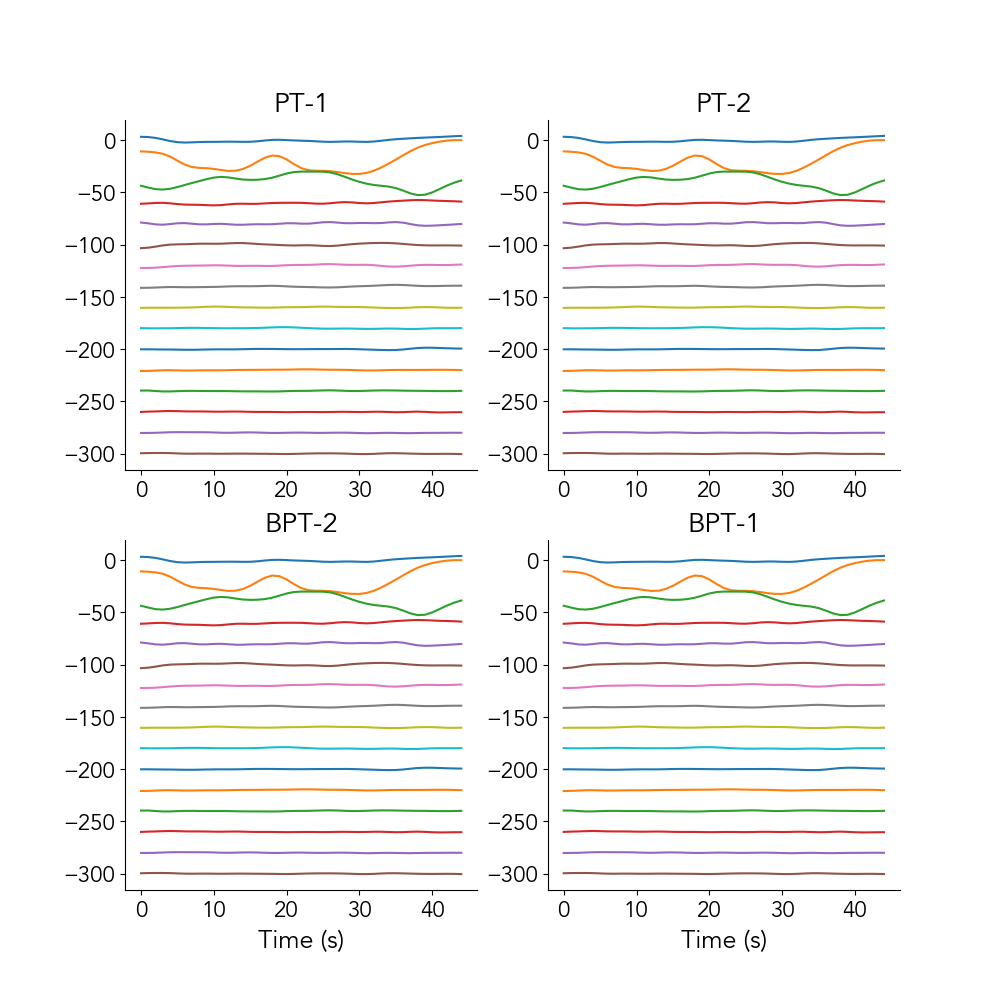

In [19]:
plot_bpt(np.tile(motion_frames_i.bpts_frames, (4,1,1)), shift = -20)

## motion

### B-Splines

INFO: MotionFieldModel initialized: mode=mrmotus, shape=(64, 64, 64), frames=10
INFO: Initializing full MR-MOTUS mode...
INFO: Building spatial B-spline bases: nx=64, ny=64, nz=64, factors=[8]
INFO: Building temporal B-spline bases: n_frames=10, factors=[2]


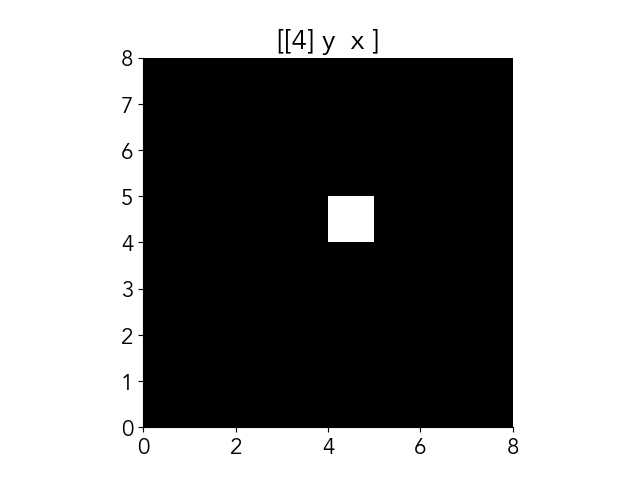

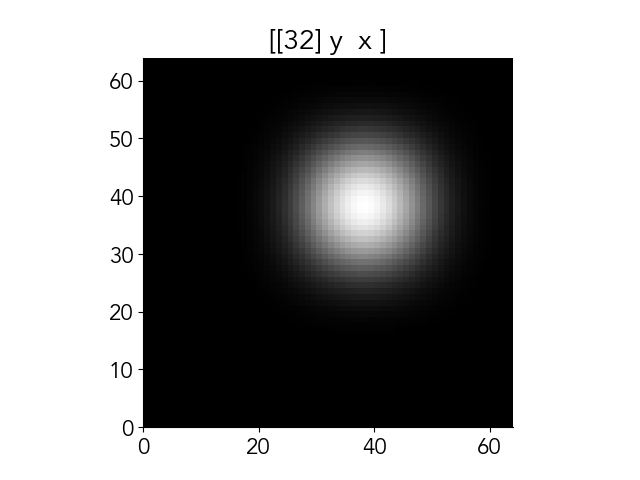

In [58]:
from bpt_motus.motion import MotionFieldModel

im_shape = (64, 64, 64)
n_frames = 10
model = MotionFieldModel(
    im_shape=im_shape, 
    n_frames=n_frames, 
    mode='mrmotus', 
    xyz_downsampling=[8], # A single scale for clarity
    t_downsampling=[2],
    n_mfcomponents=2, 
    device='cpu',
    verbose=True
)
# add a hot spot to the x-direction displacement (dim 0) for component 0
scale_key = 'scale_8'
cpx, cpy, cpz = model.xyz_ctrls[scale_key].shape[1:4]
model.xyz_ctrls[scale_key].data[0, cpx//2, cpy//2, cpz//2, 0] = 5.0 # Center bump in X
cpt = model.t_ctrls['scale_2'].shape[0]
model.t_ctrls['scale_2'].data[:, 0] = torch.linspace(0.5, 1.5, cpt)

# evaluate the motion fields vs. control points
motion_fields = model.forward() 
pl.ImagePlot(np.abs(model.xyz_ctrls[scale_key].detach().cpu().numpy())[0,...,0])
pl.ImagePlot(motion_fields.detach().cpu().numpy()[0,...,0])

### Optimization

In [60]:
# Testing motion fields classes
from bpt_motus.motion import MotionFieldModel, MotionFieldOptimizer

# Mock optimization setup with auto-loading params
calib_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/calib"
nomotion_inpdir = "/mikLKS/rinbha/BPT/MRMOTUS/test_data/bpt_motus/no_motion"

optimizer = MotionFieldOptimizer(
    calib_inpdir=calib_inpdir,
    nomotion_inpdir=nomotion_inpdir,
    mode='bpt_motus',
    xyz_downsampling=[8,16,32],
    epochs=2,
    batch_size=50,
    learning_rate=5e-2,
    patience=4,
    max_disp_frac=5e-2,
    lambda_l1=5e-1,
    device='cuda',
    verbose=True
)

optimizer.optimize()

INFO: MotionFieldModel initialized: mode=bpt_motus, shape=torch.Size([135, 135, 135]), frames=146
INFO: Initializing BPT-MOTUS mode...
INFO: Building spatial B-spline bases: nx=135, ny=135, nz=135, factors=[8, 16, 32]
INFO: Calculating scaling per frame dynamically...
  0%|                                                                                                                                            | 0/2 [00:00<?, ?it/s]/home/rinbha/Research/BPT/BPT_MOTUS/nonrigid-motion-bpt/bpt_motus/motion/optimization.py:160: ComplexWarning: Casting complex values to real discards the imaginary part
  k_pred = self._forward_model(S_warped, coords_frame, self.csm) * self.scaling_per_frame[frame_id]
INFO: Epoch 000 | DC: 8.2632e+11 | L1: 3.4045e+00 | Best: 8.2632e+11 (Epoch 0)
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [03:48<00:00, 114.22s/it]
INFO: Saving best parameters from epoch 1 and lo